kaggle房价预测


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

train_data = pd.read_csv('../data/housePrices/train.csv')
test_data = pd.read_csv('../data/housePrices/test.csv')

print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


看一下数据的样子

In [2]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


每个样本中，第一个特征是ID，将其从数据集中删除

In [3]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
print(all_features)

      MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0             60       RL         65.0     8450   Pave   NaN      Reg   
1             20       RL         80.0     9600   Pave   NaN      Reg   
2             60       RL         68.0    11250   Pave   NaN      IR1   
3             70       RL         60.0     9550   Pave   NaN      IR1   
4             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
1454         160       RM         21.0     1936   Pave   NaN      Reg   
1455         160       RM         21.0     1894   Pave   NaN      Reg   
1456          20       RL        160.0    20000   Pave   NaN      Reg   
1457          85       RL         62.0    10441   Pave   NaN      Reg   
1458          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities LotConfig  ... ScreenPorch PoolArea PoolQC  Fence  \
0            Lvl    AllPub    Inside  ...  

将所有缺失的值替换为相应特征的平均值。
通过将特征重新缩放到 零均值和单位方差(均值为0，方差为1) 来标准化数据 

In [4]:
# 先处理数值特征
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index

In [5]:
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x:(x - x.mean()) / (x.std()))  # 将数值零均值和单位方差

In [6]:
# 未采样的归0
all_features[numeric_features] = all_features[numeric_features].fillna(0)
print(all_features[numeric_features])

      MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  YearBuilt  \
0       0.067320    -0.184443 -0.217841     0.646073    -0.507197   1.046078   
1      -0.873466     0.458096 -0.072032    -0.063174     2.187904   0.154737   
2       0.067320    -0.055935  0.137173     0.646073    -0.507197   0.980053   
3       0.302516    -0.398622 -0.078371     0.646073    -0.507197  -1.859033   
4       0.067320     0.629439  0.518814     1.355319    -0.507197   0.947040   
...          ...          ...       ...          ...          ...        ...   
1454    2.419286    -2.069222 -1.043758    -1.481667     1.289537  -0.043338   
1455    2.419286    -2.069222 -1.049083    -1.481667    -0.507197  -0.043338   
1456   -0.873466     3.884968  1.246594    -0.772420     1.289537  -0.373465   
1457    0.655311    -0.312950  0.034599    -0.772420    -0.507197   0.682939   
1458    0.067320     0.201080 -0.068608     0.646073    -0.507197   0.715952   

      YearRemodAdd  MasVnrArea  BsmtFin

字符串 处理离散值， 用独热编码替换

In [7]:
# NA处理没有这个特征
all_features = pd.get_dummies(all_features, dummy_na=True, dtype=int)

print(type(all_features))

# 将True和False转换为1，0数值类型，否则后面报错
all_features = all_features * 1

all_features.shape

print(f"转后：{type(all_features)}")

<class 'pandas.core.frame.DataFrame'>
转后：<class 'pandas.core.frame.DataFrame'>


从 panda 格式中提取 NumPy格式，并将其转换为张量表示

In [8]:
n_train = train_data.shape[0]
print(n_train)

train_features = torch.tensor(all_features[:n_train].values,
                             dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values,
                             dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1,1),
                           dtype=torch.float32)

1460


训练

In [9]:
loss = nn.MSELoss()
in_features = train_features.shape[1]
print(in_features)

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net


330


房价 更可以用价格预测的对数来衡量差异，更关心相对误差 y-y_hat/y

In [10]:
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    # 预测值和真实值做log 再回归
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))
    return rmse.item()

训练函数借助Adam优化器

In [11]:
def train(net, train_features, train_labels, test_features, test_labels,
         num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # Adam对学习率不是太敏感
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate,
                                weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

K折交叉验证

In [12]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k  # 每折大小 - 样本数//k
    X_train, y_train = None, None
    for j in range(k):  # 每次把它切成 k 项
        idx = slice(j * fold_size, (j+1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        
        if j == i:  # 做验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], 0)
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

返回训练和验证误差的平均值

In [13]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate,
           weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)  # 拿到第i折
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                  weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)),[train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                    legend=['train', 'valid'], yscale='log')
        
        print(f'fold{i + 1}, train log rmse {float(train_ls[-1]):f}',
              f'valid log rmse {float(valid_ls[-1]):f}')
        
    return train_l_sum / k, valid_l_sum / k

模型选择

fold0, train log rmse 0.167701 valid log rmse 0.164181
fold2, train log rmse 0.166352 valid log rmse 0.144293
fold4, train log rmse 0.165836 valid log rmse 0.156263
fold6, train log rmse 0.159056 valid log rmse 0.221248
fold8, train log rmse 0.160918 valid log rmse 0.195288
fold10, train log rmse 0.165627 valid log rmse 0.130294
fold12, train log rmse 0.167164 valid log rmse 0.139496
fold14, train log rmse 0.164207 valid log rmse 0.165811
fold16, train log rmse 0.161886 valid log rmse 0.204662
fold18, train log rmse 0.165462 valid log rmse 0.153078
10-折验证：平均训练log rmse:0.164421 平均验证log rmse：0.167461


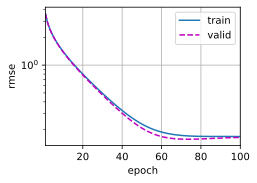

In [14]:
k, num_epochs, lr, weight_decay, batch_size = 10, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                         weight_decay, batch_size)
print(f'{k}-折验证：平均训练log rmse:{float(train_l):f}',
      f'平均验证log rmse：{float(valid_l):f}')

提交kaggle预测

train log rmse 0.162240


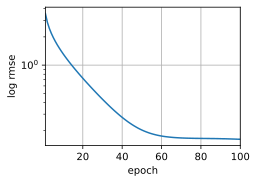

In [15]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                  num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                       num_epochs, lr, weight_decay, batch_size)
    
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
            ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    
    print(f'train log rmse {float(train_ls[-1]):f}')
    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv',index=False)
    
train_and_pred(train_features, test_features, train_labels, test_data,
              num_epochs, lr, weight_decay, batch_size)
